In [1]:
import os
import sys

import numpy as np
import pandas as pd

import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

import seaborn as sns
import matplotlib.pyplot as plt

import umap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, NMF, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

In [2]:
SEED = 42
PLOT_DPI = 100

DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2.csv"

In [3]:
dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,1.402774,90.6454,26.8508,238.852,122.664,110.082728,0.011436,...,0.205773,0.010205,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.52577,1.402774,90.7730,26.8603,223.486,121.338,88.482324,0.011561,...,0.189188,0.009251,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.49742,1.074847,90.8424,26.8616,244.904,121.664,98.062801,0.008835,...,0.174736,0.006552,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly


In [4]:
dataframe_X = dataframe.drop(columns=["anomaly", "description"])
dataframe_y = dataframe[["anomaly"]]

dataframe_X.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,1.402774,90.6454,26.8508,238.852,122.664,110.082728,0.011436,...,0.735566,0.000454,0.205773,0.010205,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:48,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:49,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:50,0.202054,0.275790,2.52577,1.402774,90.7730,26.8603,223.486,121.338,88.482324,0.011561,...,0.732637,0.000459,0.189188,0.009251,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:51,0.203595,0.278101,2.49742,1.074847,90.8424,26.8616,244.904,121.664,98.062801,0.008835,...,0.732090,0.000465,0.174736,0.006552,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(dataframe_X.to_numpy())
X_scaled

array([[ 5.77936804e-01,  7.79183394e-01,  6.45772145e-01, ...,
        -1.19787338e-01,  1.23240803e+00,  5.32112030e-01],
       [ 5.83911406e-01,  7.97831521e-01,  5.33472897e-01, ...,
        -1.19787338e-01,  1.23240803e+00,  5.32112030e-01],
       [ 5.83911406e-01,  7.97831521e-01,  5.33472897e-01, ...,
        -1.19787338e-01,  1.23240803e+00,  5.32112030e-01],
       ...,
       [-7.98123326e-01, -8.51185923e-01, -1.33261506e+00, ...,
        -4.40524476e-02, -9.26493669e-01, -5.04486097e-01],
       [-7.99511102e-01, -8.56035264e-01, -8.30555100e-01, ...,
        -2.30295131e-02, -7.92233124e-01, -4.67367495e-01],
       [-8.01906453e-01, -8.43912946e-01, -1.37053983e+00, ...,
         9.68116055e-04, -7.88997164e-01, -2.15698791e-01]],
      shape=(49202, 28))

In [16]:
dataframe_X_scaled = pd.DataFrame(X_scaled, columns=dataframe_X.columns)
dataframe_X_scaled = dataframe_X_scaled.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_scaled.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
0,0.577937,0.779183,0.645772,1.189504,1.214184,0.127393,0.847179,1.044168,-0.725188,-0.180820,...,-0.676446,0.599623,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
1,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,-0.730225,-0.246303,...,-0.547589,-0.563766,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
2,0.583911,0.797832,0.533473,-1.364447,1.230409,0.132516,-0.156807,1.037014,-0.730225,-0.246303,...,-0.547589,-0.563766,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
3,0.575260,0.783571,1.091191,1.189504,1.227769,0.131108,-0.566997,1.015068,-0.945327,-0.179284,...,-0.785866,0.341136,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly
4,0.587391,0.799515,1.055722,-0.087471,1.235157,0.131617,1.404161,1.022222,-0.847688,-0.212776,...,-0.881214,-0.389939,-0.057545,-0.333765,-0.018281,-0.119787,1.232408,0.532112,0.0,No Anomaly


### Principal Component Analysis (PCA)

In [17]:
pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print("PCA reduced data shape:", X_pca.shape)
dataframe_pca = pd.DataFrame(X_pca, columns=[f"Principal_Component_{idx}" for idx in range(1, X_pca.shape[1]+1)])
dataframe_pca = dataframe_pca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_pca.head()

PCA reduced data shape: (49202, 28)


,Principal_Component_1,Principal_Component_2,Principal_Component_3,Principal_Component_4,Principal_Component_5,Principal_Component_6,Principal_Component_7,Principal_Component_8,Principal_Component_9,Principal_Component_10,...,Principal_Component_21,Principal_Component_22,Principal_Component_23,Principal_Component_24,Principal_Component_25,Principal_Component_26,Principal_Component_27,Principal_Component_28,anomaly,description
0,3.598919,-0.795441,0.121431,1.569816,-0.825102,0.938136,0.931218,0.245988,0.638359,0.134921,...,-0.143327,0.066372,-0.022984,0.035557,-0.066668,-0.001231,-1.270214e-14,2.923049e-15,0.0,No Anomaly
1,2.826847,0.250835,-1.227721,1.568883,-0.408689,-1.420441,-0.772176,0.207510,0.261310,-0.069122,...,0.012777,0.039835,-0.050239,0.020397,-0.085683,-0.011171,-1.365857e-14,-3.518559e-14,0.0,No Anomaly
2,2.826847,0.250835,-1.227721,1.568883,-0.408689,-1.420441,-0.772176,0.207510,0.261310,-0.069122,...,0.012777,0.039835,-0.050239,0.020397,-0.085683,-0.011171,-1.365857e-14,-3.518559e-14,0.0,No Anomaly
3,3.830020,-0.689370,0.105770,1.631244,-0.773204,0.647864,0.320605,-0.090371,-0.403864,0.479578,...,-0.143660,-0.037145,-0.069545,0.053192,-0.036658,-0.010249,-1.673527e-14,-1.448795e-14,0.0,No Anomaly
4,3.497207,0.352113,-1.461103,1.399292,-0.713271,0.169534,0.514020,0.422371,0.938265,-0.106598,...,-0.117358,0.071548,-0.018681,0.007615,-0.096612,0.005636,-1.190633e-14,3.547278e-15,0.0,No Anomaly


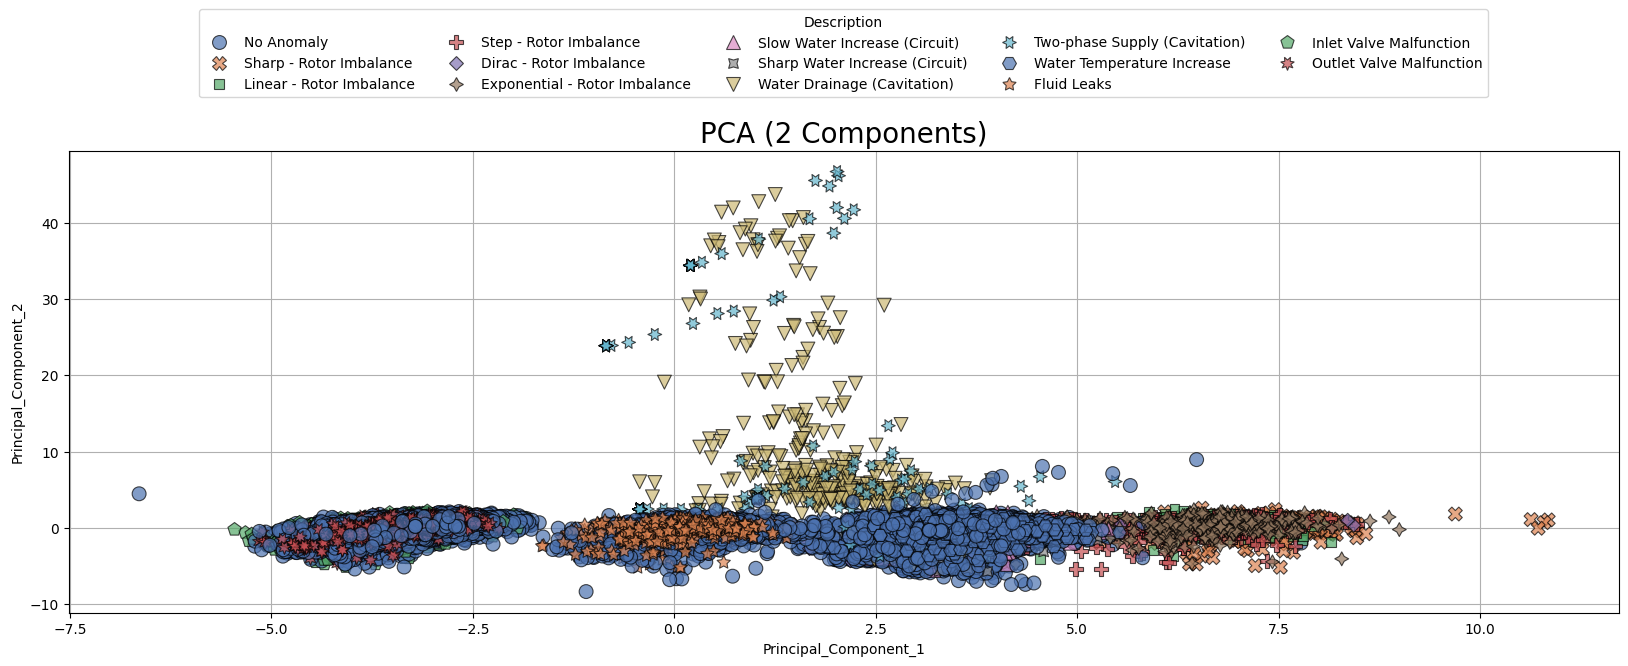

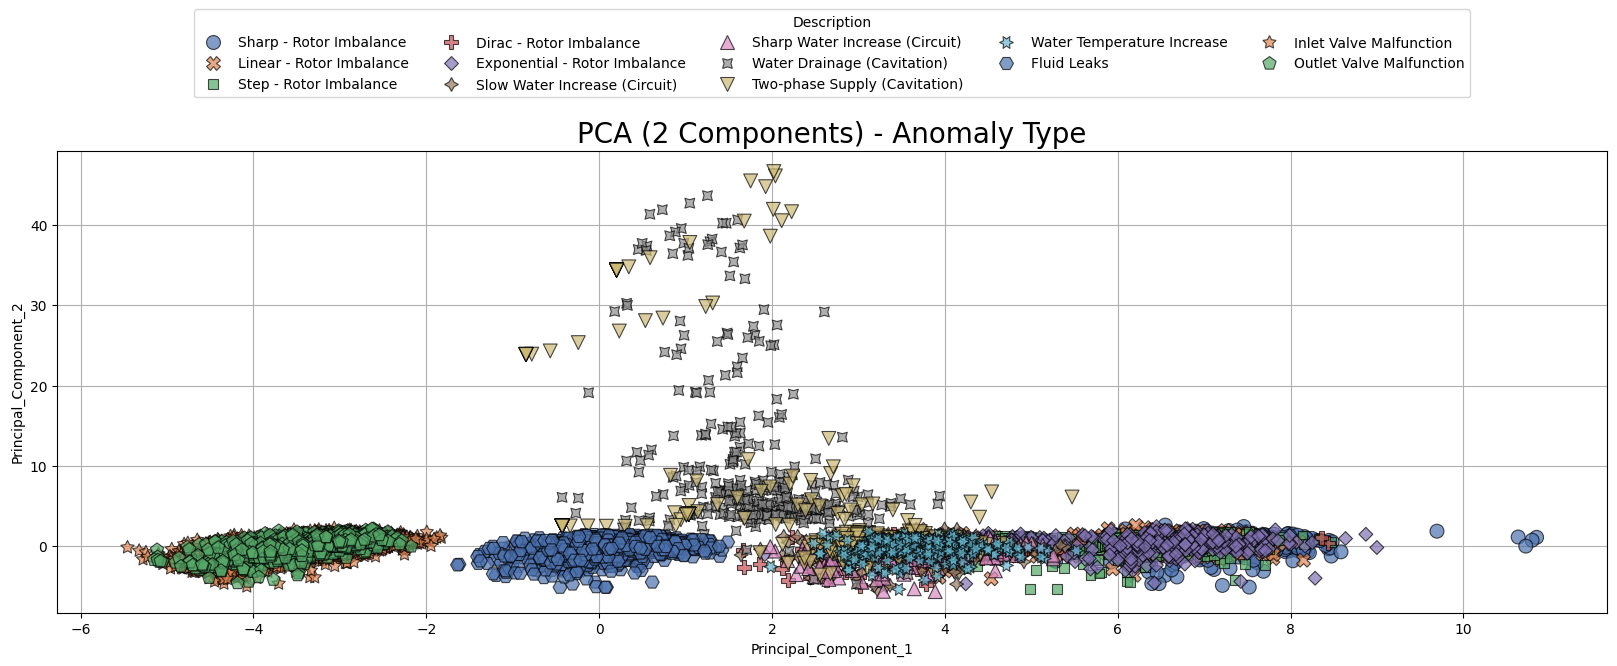

In [18]:
plot.plot_dimensional_reduction(dataframe_pca, title="PCA (2 Components)")
plot.plot_dimensional_reduction(dataframe_pca.iloc[np.where(dataframe_pca.anomaly!=0.0)], title="PCA (2 Components) - Anomaly Type")

### Linear Discriminant Analysis (LDA)

In [28]:
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, dataframe_y.to_numpy().ravel())

print("LDA reduced data shape:", X_lda.shape)
dataframe_lda = pd.DataFrame(X_lda, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, X_lda.shape[1]+1)])
dataframe_lda = dataframe_lda.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_lda.head()

LDA reduced data shape: (49202, 13)


,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,Linear_Discriminant_9,Linear_Discriminant_10,Linear_Discriminant_11,Linear_Discriminant_12,Linear_Discriminant_13,anomaly,description
0,-0.562462,-0.287713,0.141480,-0.523363,2.363758,-1.268773,-0.196523,-2.514206,-0.330483,-1.507138,0.469232,-0.982311,-1.565694,0.0,No Anomaly
1,-0.523552,-0.094059,0.382368,-0.426403,2.618839,-1.496670,-0.288046,-2.852556,-0.196440,-0.844004,0.768967,-0.088691,0.020813,0.0,No Anomaly
2,-0.523552,-0.094059,0.382368,-0.426403,2.618839,-1.496670,-0.288046,-2.852556,-0.196440,-0.844004,0.768967,-0.088691,0.020813,0.0,No Anomaly
3,-0.645048,-0.063463,0.310459,-0.584109,2.511785,-1.179795,0.096105,-2.501578,-0.181455,-0.576953,-0.014772,-0.001030,-0.412674,0.0,No Anomaly
4,-0.575545,0.004856,0.325721,-0.489308,2.643918,-1.448367,-0.018978,-2.649424,-0.210081,-1.294597,0.952724,-0.802661,-1.451334,0.0,No Anomaly


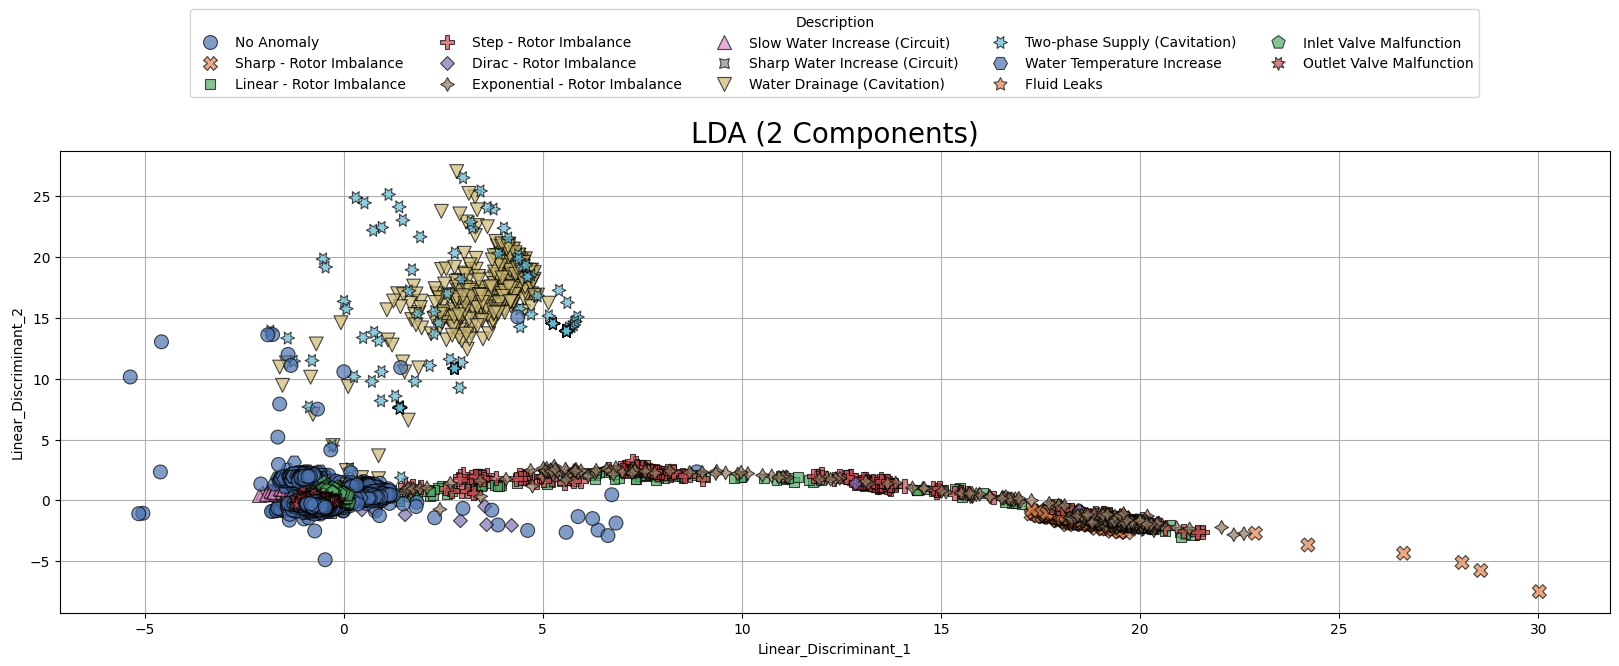

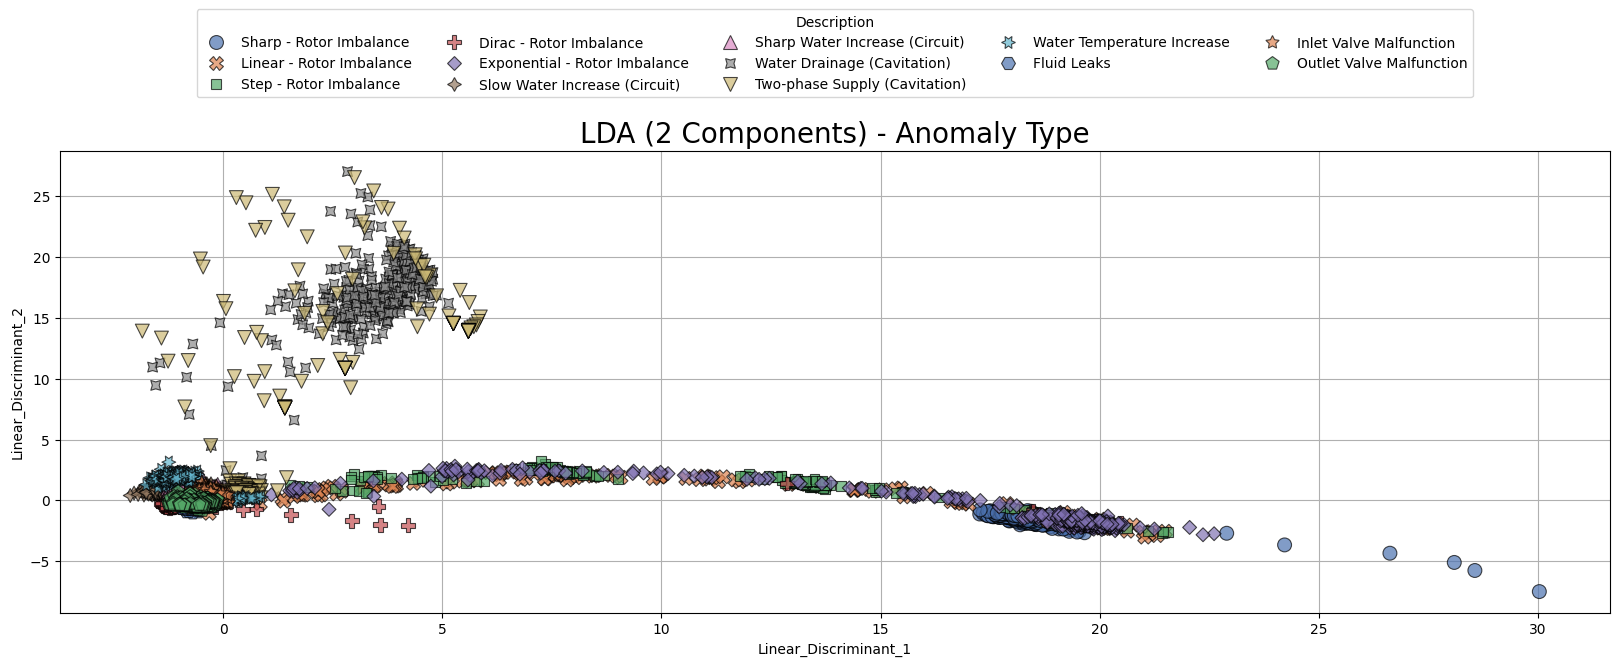

In [31]:
plot.plot_dimensional_reduction(dataframe_lda, title="LDA (2 Components)")
plot.plot_dimensional_reduction(dataframe_lda.iloc[np.where(dataframe_lda.anomaly!=0.0)], title="LDA (2 Components) - Anomaly Type")

### Non-Negative Matrix Factorization (NMF)

In [39]:
# For NMF, the input data must be non-negative.
X_nmf_positive = dataframe_X.to_numpy() - dataframe_X.to_numpy().min() # Simple way to make it non-negative for demo
nmf = NMF(n_components=None, init='random', random_state=SEED, max_iter=500)
X_nmf = nmf.fit_transform(X_nmf_positive)

print("NMF reduced data shape:", X_nmf.shape)
dataframe_nmf = pd.DataFrame(X_nmf, columns=[f"NMF_Component_{idx}" for idx in range(1, X_nmf.shape[1]+1)])
dataframe_nmf = dataframe_nmf.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_nmf

NMF reduced data shape: (49202, 28)


,NMF_Component_1,NMF_Component_2,NMF_Component_3,NMF_Component_4,NMF_Component_5,NMF_Component_6,NMF_Component_7,NMF_Component_8,NMF_Component_9,NMF_Component_10,...,NMF_Component_21,NMF_Component_22,NMF_Component_23,NMF_Component_24,NMF_Component_25,NMF_Component_26,NMF_Component_27,NMF_Component_28,anomaly,description
0,24.484437,19.744764,0.206867,0.000000,0.000000,3.673432,2.436301,0.047616,0.122722,0.000000,...,0.000000,0.133564,0.000000,0.000000,0.000000,0.000000,0.029446,0.000000,0.0,No Anomaly
1,21.297046,8.171009,0.160975,22.391221,0.001025,11.885354,0.061532,0.042234,0.108130,0.003739,...,0.044567,1.019158,0.002889,0.023003,0.011410,3.274687,0.019741,0.000000,0.0,No Anomaly
2,20.963148,8.457923,0.186183,24.805106,0.001666,11.151300,0.259112,0.046256,0.106278,0.003789,...,0.073473,1.058712,0.003427,0.020184,0.012471,3.322832,0.071366,0.000000,0.0,No Anomaly
3,25.944593,21.131250,0.075409,0.376676,0.000000,0.000000,1.156924,0.041233,0.138740,0.000000,...,0.000221,0.017520,0.000000,0.001780,0.000000,0.000000,0.162812,0.000000,0.0,No Anomaly
4,27.259343,14.872970,0.089442,17.522882,0.000003,6.655402,0.040656,0.019334,0.137211,0.000559,...,0.000000,0.255928,0.000301,0.016246,0.000000,0.053684,0.016626,0.000000,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49197,9.191270,0.775588,0.647264,2.931776,0.000571,5.867191,0.051158,0.148214,0.090015,0.006352,...,6.396876,0.025388,1.859245,0.001433,0.000288,7.829854,0.007881,3.095289,0.0,No Anomaly
49198,10.386932,0.090036,1.240511,6.629514,0.003851,5.928172,0.000000,0.100436,0.133817,0.005993,...,6.675216,0.000000,0.010686,0.000000,0.022682,5.533239,0.000000,1.568369,0.0,No Anomaly
49199,4.122579,3.154906,0.156735,1.809941,0.002244,2.801154,0.010549,2.928616,0.061141,0.004557,...,11.511890,0.053307,2.064046,0.002520,0.000132,11.826087,0.042898,0.073795,0.0,No Anomaly
49200,7.816235,0.020255,1.081008,16.100182,0.003274,8.110538,0.001670,0.061038,0.084635,0.006910,...,7.072777,0.000000,0.054766,0.000876,0.003399,6.734503,0.030240,3.808985,0.0,No Anomaly


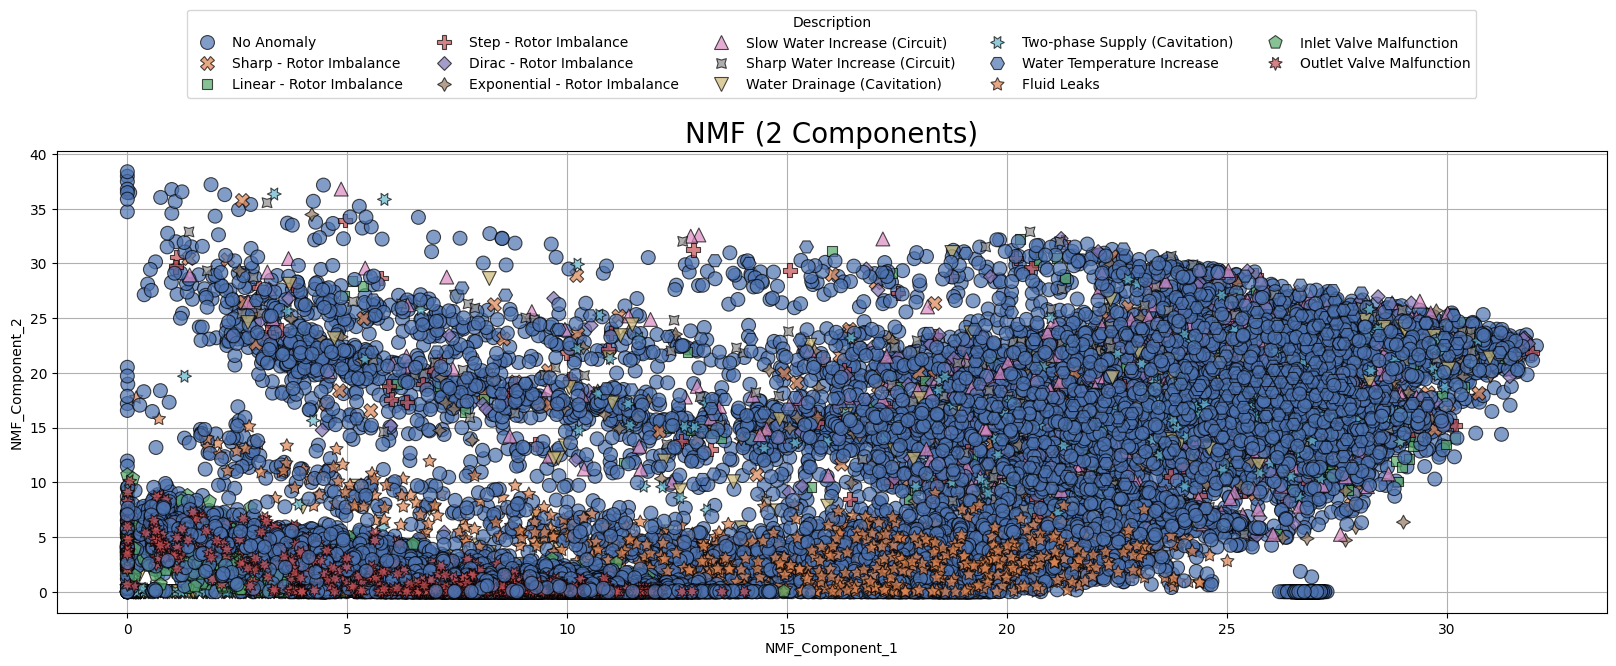

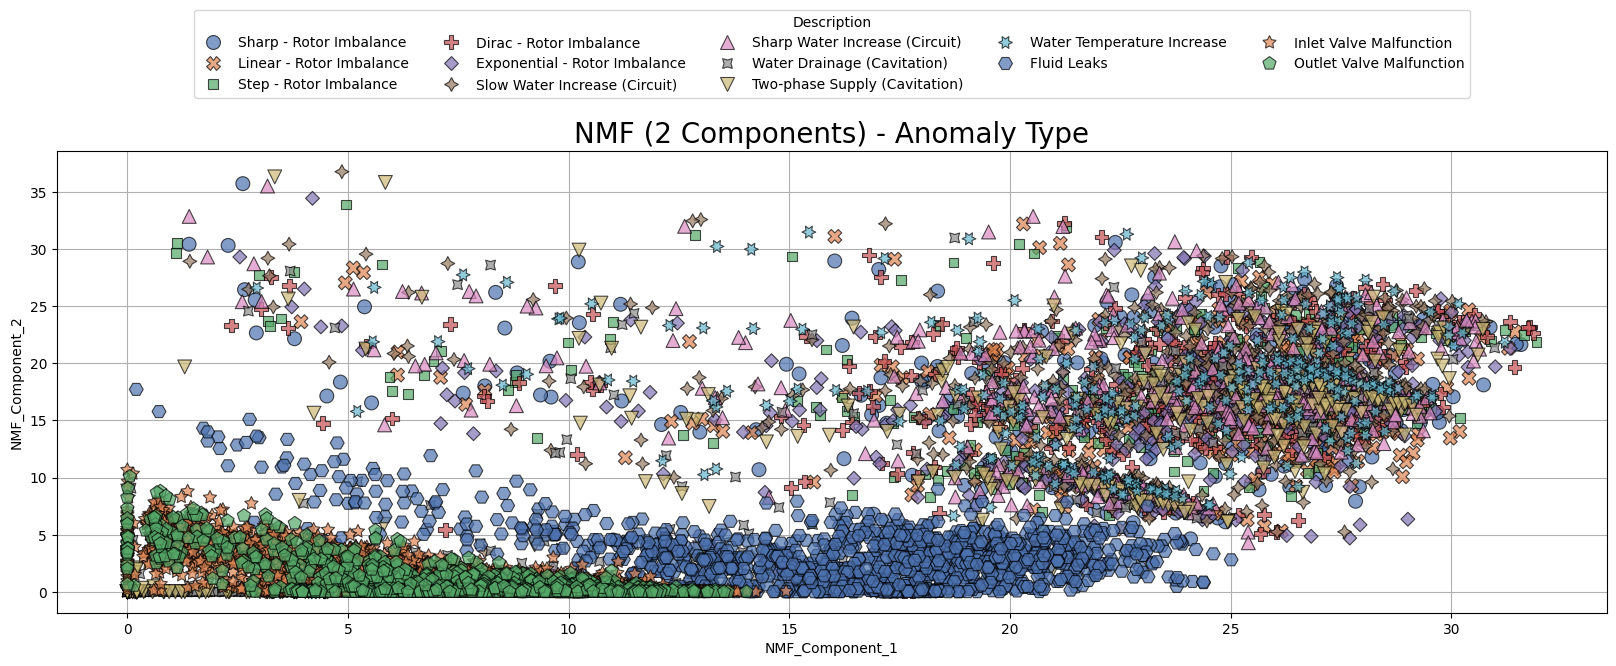

In [40]:
plot.plot_dimensional_reduction(dataframe_nmf, title="NMF (2 Components)")
plot.plot_dimensional_reduction(dataframe_nmf.iloc[np.where(dataframe_nmf.anomaly!=0.0)], title="NMF (2 Components) - Anomaly Type")

### Kernel Principal Component Analysis (KPCA)

In [49]:
kpca = KernelPCA(n_components=5, kernel="rbf", random_state=SEED)
X_kpca = kpca.fit_transform(X_scaled)

print("Kernel PCA reduced data shape:", X_kpca.shape)
dataframe_kpca = pd.DataFrame(X_kpca, columns=[f"K_Principal_Component_{idx}" for idx in range(1, X_kpca.shape[1]+1)])
dataframe_kpca = dataframe_kpca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_kpca

Kernel PCA reduced data shape: (49202, 5)


,K_Principal_Component_1,K_Principal_Component_2,K_Principal_Component_3,K_Principal_Component_4,K_Principal_Component_5,anomaly,description
0,0.555578,0.065800,0.054629,-0.237664,-0.032669,0.0,No Anomaly
1,0.483090,0.014228,0.256920,0.146949,-0.196031,0.0,No Anomaly
2,0.483090,0.014228,0.256920,0.146949,-0.196031,0.0,No Anomaly
3,0.583531,0.053085,0.044506,-0.224367,-0.036494,0.0,No Anomaly
4,0.550073,-0.032913,0.183547,0.075849,-0.229152,0.0,No Anomaly
...,...,...,...,...,...,...,...
49197,-0.569629,-0.132295,-0.004409,-0.053896,-0.042933,0.0,No Anomaly
49198,-0.568458,-0.130739,-0.004885,-0.053554,-0.042135,0.0,No Anomaly
49199,-0.477794,0.347383,-0.309313,0.117167,-0.171510,0.0,No Anomaly
49200,-0.509906,-0.221443,0.127172,0.166472,0.148292,0.0,No Anomaly


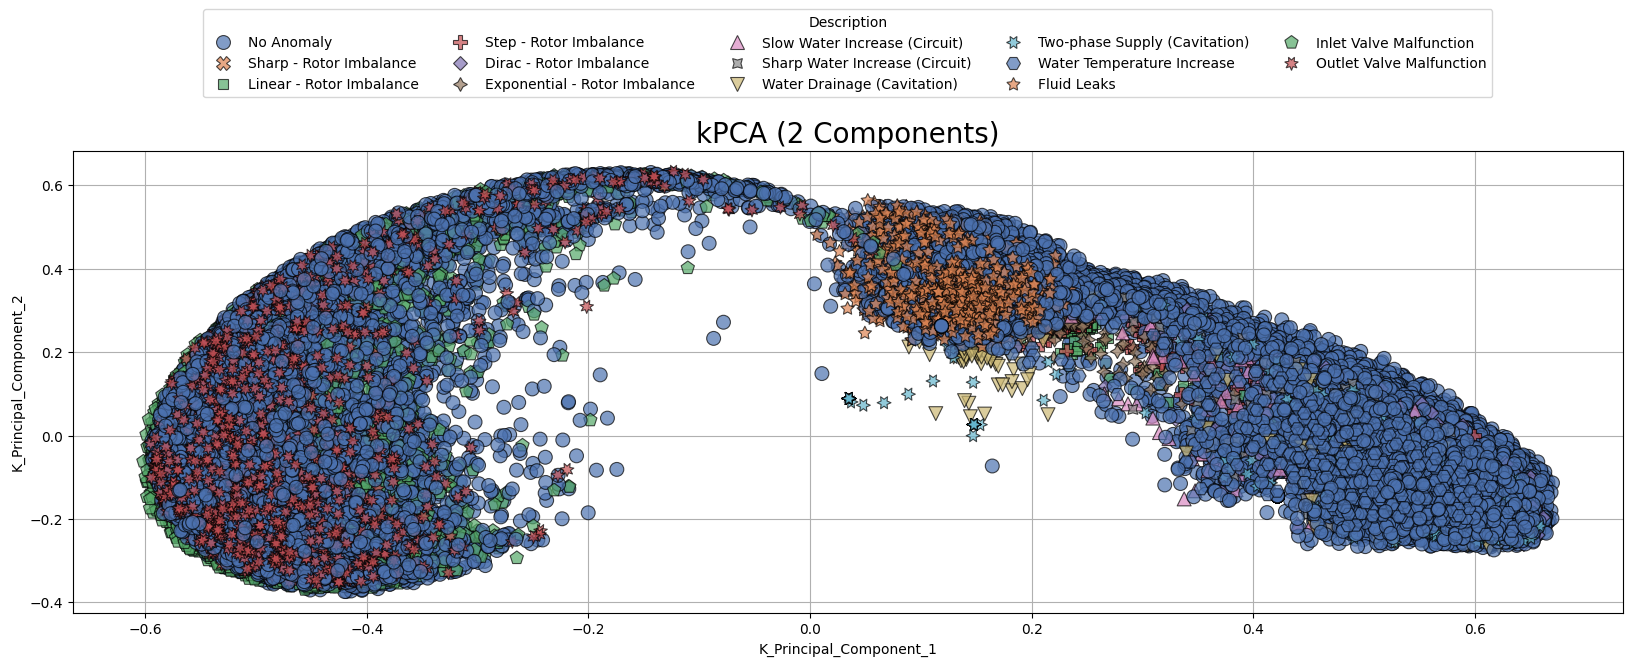

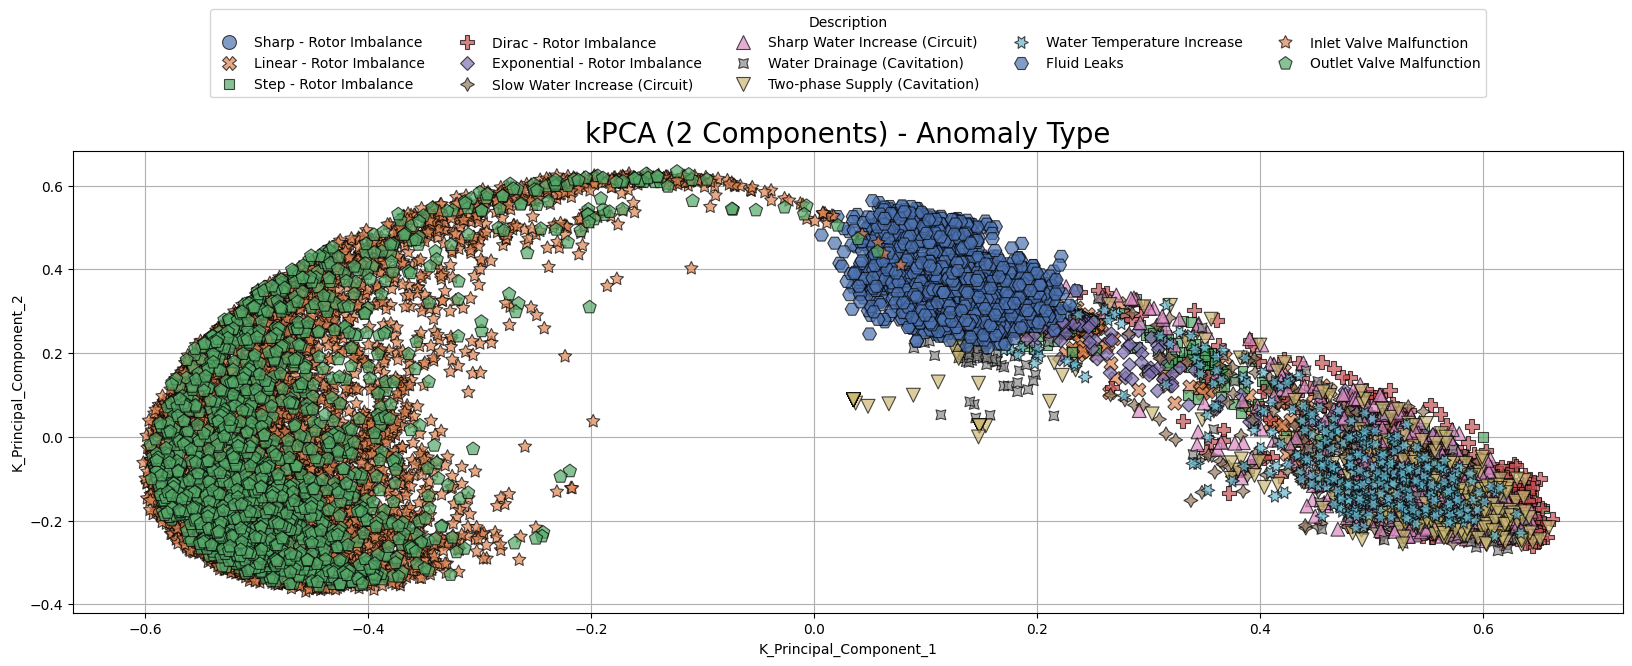

In [50]:
plot.plot_dimensional_reduction(dataframe_kpca, title="kPCA (2 Components)")
plot.plot_dimensional_reduction(dataframe_kpca.iloc[np.where(dataframe_kpca.anomaly!=0.0)], title="kPCA (2 Components) - Anomaly Type")

In [51]:
def get_tsne_components(dataframe, n_components=2):
    tmp = dataframe.drop(["anomaly", "description"], axis=1)
    tsne = TSNE(n_components=n_components, random_state=SEED, perplexity=50, n_jobs=5)
    X_tsne = tsne.fit_transform(tmp.values)

    print("t-SNE reduced data shape:", X_tsne.shape)
    dataframe_tsne = pd.DataFrame(X_tsne, columns=[f"tSNE_Component_{idx}" for idx in range(1, n_components+1)])
    dataframe_tsne = dataframe_tsne.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
    return dataframe_tsne

In [52]:
def get_umap_components(dataframe, n_components=2):
    tmp = dataframe.drop(["anomaly", "description"], axis=1)
    reducer = umap.UMAP(n_components=n_components, random_state=SEED)
    X_umap = reducer.fit_transform(tmp.values)

    print("UMAP reduced data shape:", X_umap.shape)
    dataframe_umap = pd.DataFrame(X_umap, columns=[f"UMAP_Component_{idx}" for idx in range(1, n_components+1)])
    dataframe_umap = dataframe_umap.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
    return dataframe_umap

t-SNE reduced data shape: (49202, 2)


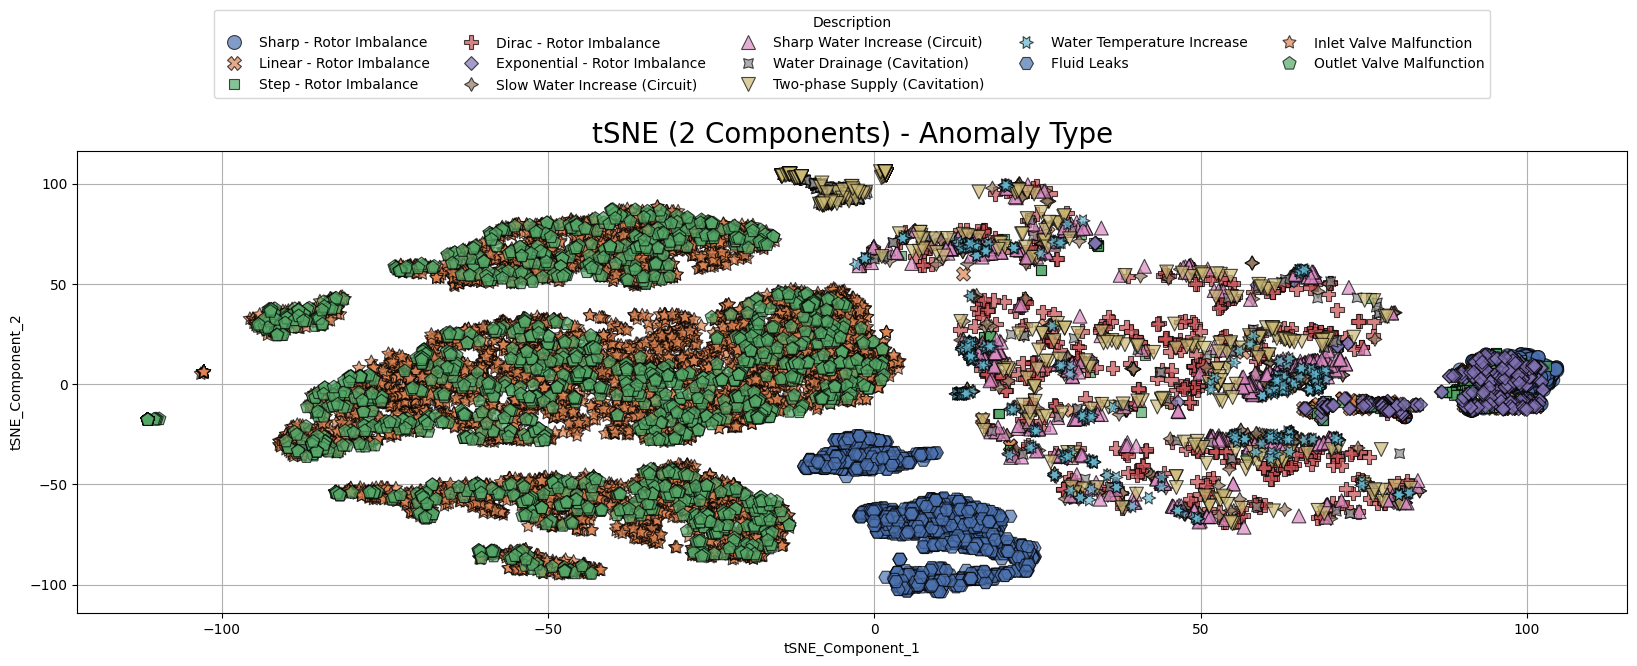

t-SNE reduced data shape: (49202, 2)


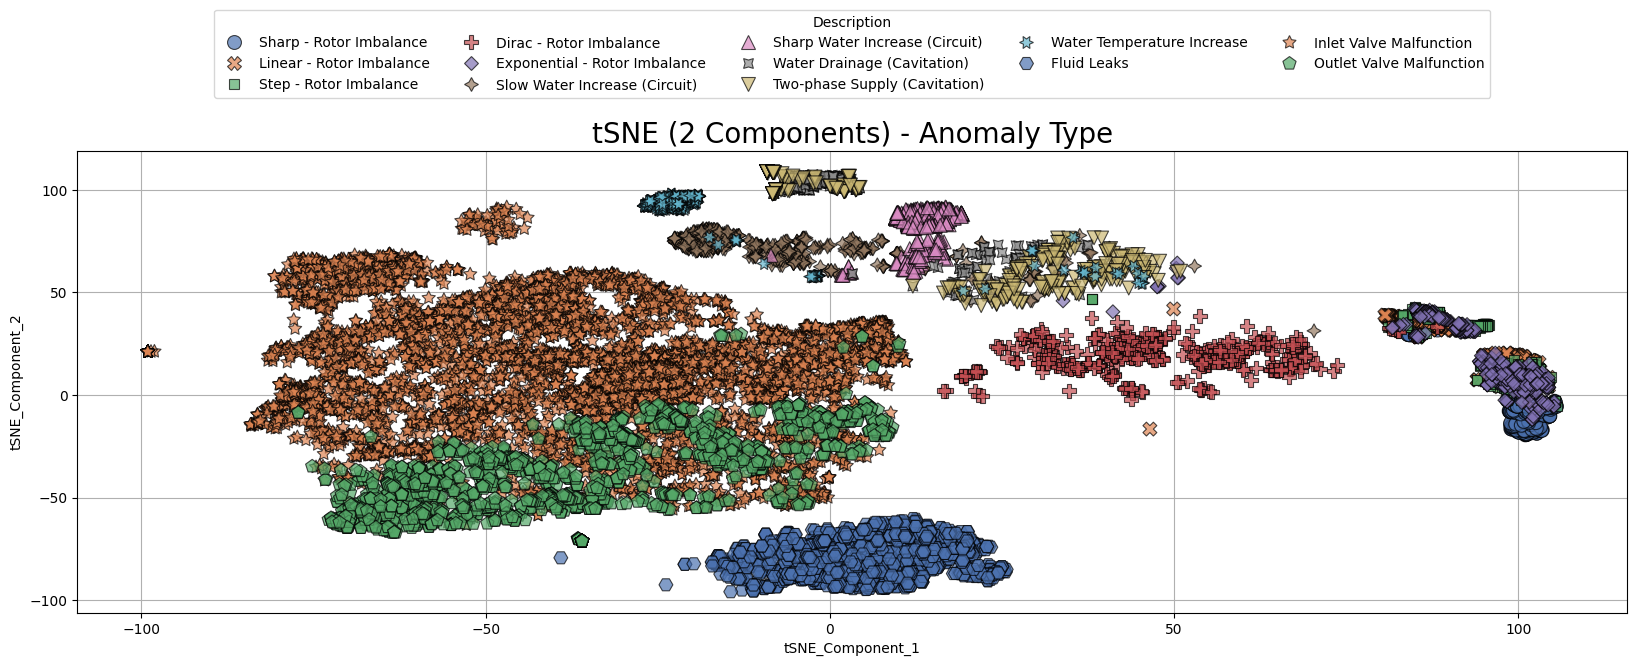

In [55]:
dataframe_X_scaled_tsne = get_tsne_components(dataframe_X_scaled)

# plot.plot_dimensional_reduction(dataframe_X_scaled_tsne, title="tSNE (2 Components)")
plot.plot_dimensional_reduction(dataframe_X_scaled_tsne.iloc[np.where(dataframe_X_scaled_tsne.anomaly!=0.0)], title="tSNE (2 Components) - Anomaly Type")

dataframe_X_scaled_tsne = get_tsne_components(dataframe_lda)

# plot.plot_dimensional_reduction(dataframe_X_scaled_tsne, title="tSNE (2 Components)")
plot.plot_dimensional_reduction(dataframe_X_scaled_tsne.iloc[np.where(dataframe_X_scaled_tsne.anomaly!=0.0)], title="tSNE (2 Components) - Anomaly Type")

UMAP reduced data shape: (49202, 2)


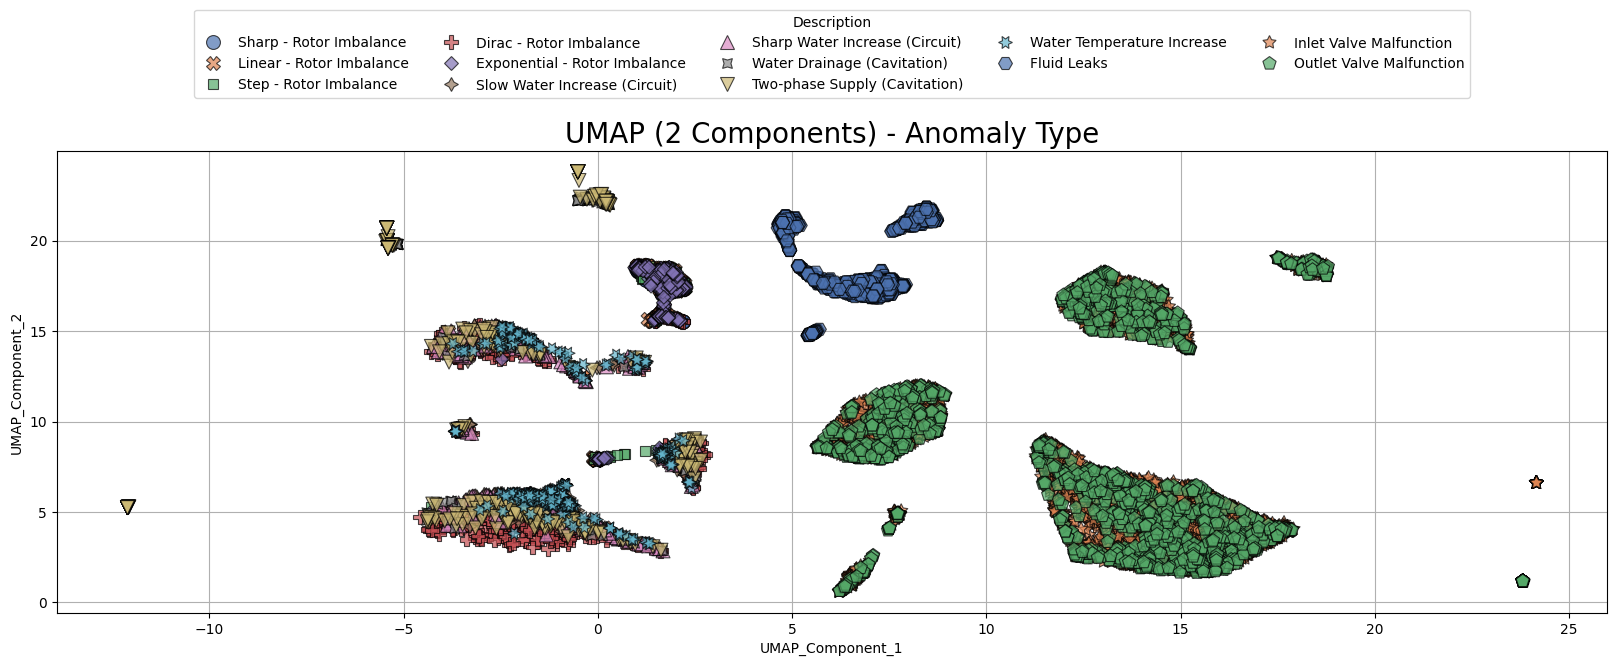

UMAP reduced data shape: (49202, 2)


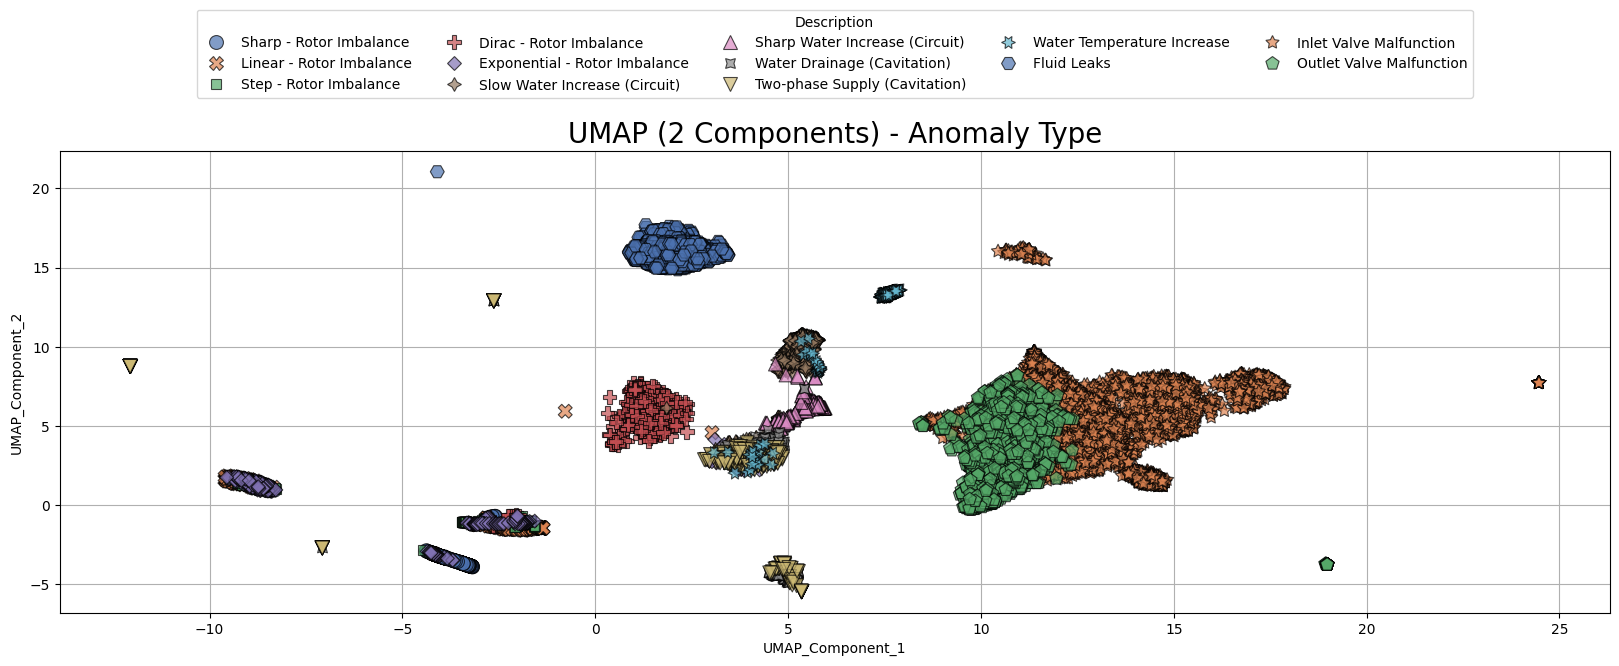

In [56]:
dataframe_X_scaled_umap = get_umap_components(dataframe_X_scaled)

# plot.plot_dimensional_reduction(dataframe_X_scaled_umap, title="UMAP (2 Components)")
plot.plot_dimensional_reduction(dataframe_X_scaled_umap.iloc[np.where(dataframe_X_scaled_umap.anomaly!=0.0)], title="UMAP (2 Components) - Anomaly Type")

dataframe_X_scaled_umap = get_umap_components(dataframe_lda)

# plot.plot_dimensional_reduction(dataframe_X_scaled_umap, title="UMAP (2 Components)")
plot.plot_dimensional_reduction(dataframe_X_scaled_umap.iloc[np.where(dataframe_X_scaled_umap.anomaly!=0.0)], title="UMAP (2 Components) - Anomaly Type")